# EDC Explorer

Pick one of the `.npz` files produced by `rir_hoa.py`, then compute and plot the
per-frequency-band Energy Decay Curve (EDC) for a chosen microphone / HOA channel,
using `analysis.compute_edc`.

**How to use:** run the cells top to bottom. Whenever you change a dropdown value,
re-run the cell(s) below it to refresh the results.

In [1]:
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import pyfar as pf

import analysis

## 1. Select an npz file

Update `DATA_ROOT` if your files live somewhere else (it should match the
`--output_dir` used with `rir_hoa.py`).

In [2]:
DATA_ROOT = Path("/Users/dalsag1/Documents/datasets/treble10-npz")

npz_files = sorted(DATA_ROOT.rglob("*.npz"))
print(f"Found {len(npz_files)} npz files under {DATA_ROOT}")

file_dropdown = widgets.Dropdown(
    options=[(str(p.relative_to(DATA_ROOT)), p) for p in npz_files],
    description="RIR file:",
    layout=widgets.Layout(width="700px"),
    style={"description_width": "initial"},
)
display(file_dropdown)

Found 1 npz files under /Users/dalsag1/Documents/datasets/treble10-npz


Dropdown(description='RIR file:', layout=Layout(width='700px'), options=(('rir-hoa8/living_room_w_hallway1/dat…

## 2. Load the selected file

`rir_hoa.py` saves one file per (room, source) with the RIRs of all mic positions
stacked along axis 0, so we reshape back to `(n_mics, n_samples, n_hoa_channels)`.

In [3]:
def load_rir_file(path):
    data = np.load(path)
    fs = int(data["fs"])
    posMic = data["posMic"]  # (n_mics, 3)
    posSrc = data["posSrc"]  # (3,)
    n_mics = posMic.shape[0]
    rir = data["rir"].reshape(n_mics, -1, data["rir"].shape[-1])  # (n_mics, n_samples, n_hoa)
    return rir, fs, posMic, posSrc


rir, fs, posMic, posSrc = load_rir_file(file_dropdown.value)
n_mics, n_samples, n_hoa = rir.shape

print(f"Loaded: {file_dropdown.label}")
print(f"  fs = {fs} Hz")
print(f"  {n_mics} mic positions, {n_samples} samples, {n_hoa} HOA channels (ACN order, channel 0 = W / omni)")
print(f"  source position = {posSrc}")

Loaded: rir-hoa8/living_room_w_hallway1/data_s0001.npz
  fs = 32000 Hz
  97 mic positions, 32001 samples, 81 HOA channels (ACN order, channel 0 = W / omni)
  source position = [-2.4  -2.05  1.95]


## 3. Choose mic, HOA channel and octave-band resolution

In [4]:
mic_dropdown = widgets.Dropdown(options=list(range(n_mics)), value=0, description="Mic index:")
channel_dropdown = widgets.Dropdown(options=list(range(n_hoa)), value=0, description="HOA channel:")
fraction_dropdown = widgets.Dropdown(
    options=[("Octave", 1), ("1/3 octave", 3)], value=1, description="Band width:"
)

display(widgets.HBox([mic_dropdown, channel_dropdown, fraction_dropdown]))

## 4. Compute and plot the EDC per frequency band

Uses `analysis.compute_edc(..., use_filterbank=True)`, which applies a fractional-octave
filterbank and Schroeder backward integration to each band.

/Users/dalsag1/miniconda3/envs/treble10-analyzer/lib/python3.11/site-packages/pyfar/dsp/filter/fractional_octaves.py:44: PyfarDeprecationWarning: '`pyfar.dsp.filter.fractional_octave_frequencies` will be deprecated in pyfar 0.10.0. Use `pyfar.constants.fractional_octave_frequencies_exact` or `pyfar.constants.fractional_octave_frequencies_nominal` instead.'
  warnings.warn(("`pyfar.dsp.filter.fractional_octave_frequencies` will be "
/Users/dalsag1/miniconda3/envs/treble10-analyzer/lib/python3.11/site-packages/pyfar/dsp/filter/fractional_octaves.py:292: UserWarning: The upper frequency limit 22387.2 Hz is above the Nyquist frequency. Using a highpass filter instead of a bandpass.
  sos = _coefficients_fractional_octave_bands(


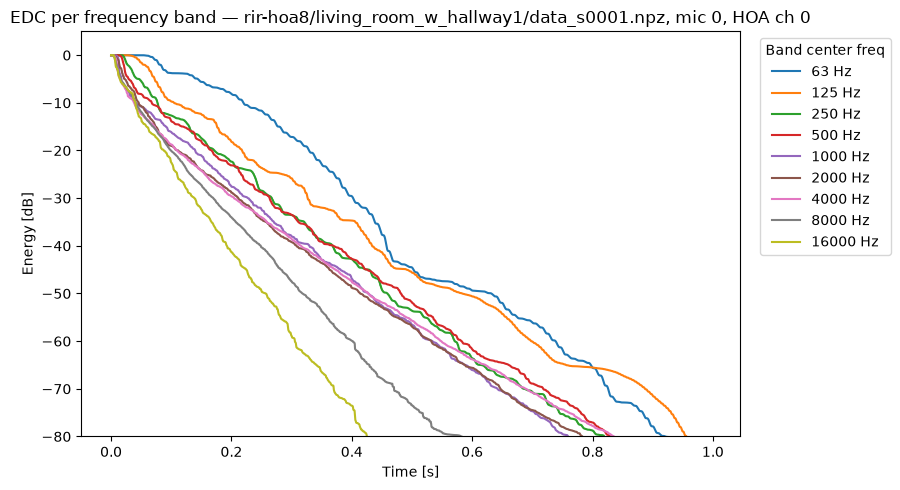

In [5]:
F_MIN, F_MAX = 63, 16000


def get_center_frequencies(n_fractions, f_min=F_MIN, f_max=F_MAX):
    return pf.dsp.filter.fractional_octave_frequencies(
        num_fractions=n_fractions, frequency_range=(f_min, f_max), return_cutoff=False
    )[0]


def compute_band_edc(rir, mic_idx, hoa_channel, fs, n_fractions):
    x = rir[mic_idx, :, hoa_channel]
    x_t = torch.from_numpy(x).float().unsqueeze(0)  # (1, n_samples)
    edc_db = analysis.compute_edc(
        x_t, use_filterbank=True, n_fractions=n_fractions, f_min=F_MIN, f_max=F_MAX, fs=fs
    )  # (n_bands, n_samples)
    center_freqs = get_center_frequencies(n_fractions)
    return edc_db, center_freqs


edc_db, center_freqs = compute_band_edc(
    rir, mic_dropdown.value, channel_dropdown.value, fs, fraction_dropdown.value
)
time = np.arange(edc_db.shape[-1]) / fs

fig, ax = plt.subplots(figsize=(9, 5))
for band_edc, f_c in zip(edc_db.numpy(), center_freqs):
    ax.plot(time, band_edc, label=f"{f_c:.0f} Hz")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Energy [dB]")
ax.set_ylim(-80, 5)
ax.set_title(f"EDC per frequency band \u2014 {file_dropdown.label}, mic {mic_dropdown.value}, HOA ch {channel_dropdown.value}")
ax.legend(title="Band center freq", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

## 5. RT60 per band

Fits `analysis.estimate_rt60` to each band's EDC using the default -5 dB to -35 dB decay range.

In [6]:
time_t = torch.arange(edc_db.shape[-1]) / fs

print(f"{'Freq [Hz]':>10}  {'RT60 [s]':>10}")
for band_edc, f_c in zip(edc_db, center_freqs):
    rt60, slope, intercept, valid_range = analysis.estimate_rt60(band_edc, time_t)
    print(f"{f_c:10.0f}  {rt60:10.3f}")

 Freq [Hz]    RT60 [s]
        63       0.591
       125       0.667
       250       0.563
       500       0.579
      1000       0.539
      2000       0.507
      4000       0.521
      8000       0.388
     16000       0.299
